### 7.2.2 랜덤 포레스트 분류 모델 구현하기

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# 1. 아이리스(Iris) 데이터셋 로드
# 'frame': 특성(4개)과 타깃(1개)이 합쳐진 데이터프레임 (총 150행 5열)
df = load_iris(as_frame=True)['frame']
print(f'df type: {type(df)}')

# 2. 이진 분류(Binary Classification) 환경 구축
# target이 0(Setosa), 1(Versicolor)인 데이터만 추출 (총 100행)
df = df[df['target'] <= 1]

# 3. 데이터 무작위 셔플 (frac=1: 전체 데이터 100% 샘플링, random_state: 난수 고정)
df = df.sample(frac=1, random_state=1234)

# 4. 학습용(75개) 및 테스트용(25개) 데이터셋 분할
train, test = df.iloc[:75, :], df.iloc[75:, :]

# 5. 학습/테스트 데이터에서 독립변수(X)와 종속변수(y) 분리
X_train, y_train = train.iloc[:, :-1], train.iloc[:, -1]
X_test, y_test = test.iloc[:, :-1], test.iloc[:, -1]

# 6. 특성 컬럼명 목록(X_cols)과 타깃 컬럼명(y_col='target') 분리
X_cols, y_col = train.columns.tolist()[:-1], train.columns.tolist()[-1]


# 7. 분기 노드의 지니 불순도(Gini Impurity) 가중평균 계산 함수
def eval_gini(left, right, y_col):
    gini, n1, n2 = 0, len(left), len(right)

    # [왼쪽 자식 노드] 지니 불순도 = 1 - sum(p_i^2) 계산 후 전체 대비 샘플 비율(n1/(n1+n2)) 가중치 곱셈
    score = 1 - ((left[y_col].value_counts())**2).sum() / (n1**2)
    gini += score * n1 / (n1 + n2)

    # [오른쪽 자식 노드] 지니 불순도 계산 후 샘플 비율(n2/(n1+n2)) 가중치 곱셈
    score = 1 - ((right[y_col].value_counts())**2).sum() / (n2**2)
    gini += score * n2 / (n1 + n2)

    return gini


# 8. 최종 리프 노드에서 가장 많은 빈도를 차지한 클래스(최빈값)를 반환하는 함수
def eval_class(df, y_col):
    # 빈도수 기준 내림차순 정렬 후 가장 첫 번째(최다 득표) 클래스 인덱스 선택
    return df[y_col].value_counts().sort_values(ascending=False).index[0]

df type: <class 'pandas.DataFrame'>


In [2]:
def base_tree(train, X_cols, y_col, max_depth=4, min_samples_split=4):
    # 1. 완전 이진 트리 배열 초기화 (최대 깊이에 맞게 2^(max_depth + 1) 크기 확보)
    tree = []
    for i in range(0, 2**(max_depth + 1)):
        tree.append(dict({'struct': None}))

    # 2. 루트 노드(인덱스 1)에 전체 학습 데이터프레임 할당
    tree[1]['struct'] = train

    # 3. 배열 순회를 통한 너비 우선 탐색(BFS) 기반 트리 분기 수행
    for i in range(1, len(tree)):
        # 현재 노드가 데이터프레임 형태가 아니면(이미 리프 노드이거나 비어있으면) 스킵
        if not isinstance(tree[i]['struct'], pd.DataFrame):
            continue

        # 4. 최대 깊이에 도달한 노드는 다수결 최빈값 클래스로 결정하여 리프 노드화
        if i >= 2**max_depth:
            tree[i]['struct'] = eval_class(tree[i]['struct'], y_col)
            continue

        data = tree[i]['struct']
        a, b, c, d, e = '', float('inf'), float('inf'), None, None

        # 5. 모든 특성과 분기점 후보를 탐색하여 지니 불순도(c)를 최소화하는 최적 분기점 탐색
        for X_col in X_cols:
            vals = np.sort(data[X_col].unique())
            for val in vals[1:]:
                left, right = data[data[X_col] < val], data[data[X_col] >= val]
                gini = eval_gini(left, right, y_col)
                if gini < c:
                    a, b, c, d, e = X_col, val, gini, left, right

        # 6. 최적 분기 정보(분기 특성명, 기준값) 노드에 기록
        tree[i]['col'] = a
        tree[i]['val'] = b

        # 7. 왼쪽 자식 노드(i << 1) 처리 (최소 샘플 수 min_samples_split 검사)
        # [버그 수정]: d(왼쪽 그룹)의 샘플 수 부족 시 e가 아닌 d의 최빈값을 할당하도록 수정
        if d is not None and len(d) >= min_samples_split:
            tree[i << 1]['struct'] = d
        elif d is not None:
            tree[i << 1]['struct'] = eval_class(d, y_col)  # (기존 e -> d로 수정)

        # 8. 오른쪽 자식 노드((i << 1) + 1) 처리
        if e is not None and len(e) >= min_samples_split:
            tree[(i << 1) + 1]['struct'] = e
        elif e is not None:
            tree[(i << 1) + 1]['struct'] = eval_class(e, y_col)

    return tree

In [3]:
max_samples = 0.3
forest = []

for i in range(9):
    # 1. random_state=1234 + i 로 설정하여 반복할 때마다 다른 샘플 데이터셋 추출
    # 2. replace=True(복원 추출) 옵션을 추가하면 전통적인 배깅(Bagging) 부트스트래핑 방식으로 동작합니다.
    train0 = train.sample(frac=max_samples, replace=True, random_state=1234 + i)

    # 서로 다른 데이터 서브세트로 학습된 트리를 숲(forest)에 추가
    forest.append(base_tree(train0, X_cols, y_col))

랜덤 포레스트(숲) 내부의 개별 결정 트리를 순회하면서 테스트 데이터에 대한 예측 및 하드 보팅(Hard Voting, 다수결)을 수행하고 정확도를 측정

In [4]:
cnt = 0  # 정답을 맞춘 테스트 샘플 개수 카운터

# 1. 테스트 데이터셋(X_test)의 각 샘플(행)을 한 개씩 순회
for i in range(len(X_test)):
    row = X_test.iloc[i]  # i번째 테스트 데이터 (단일 샘플)
    y_pred = [0, 0]       # 클래스 0과 클래스 1의 득표수를 저장할 리스트 [0클래스 득표, 1클래스 득표]

    # 2. 앙상블 숲(forest) 내의 모든 개별 트리(tree)에 대해 예측 수행
    for tree in forest:
        ind = 1           # 루트 노드 인덱스(1)부터 탐색 시작
        node = tree[ind]

        # 노드의 'struct'가 데이터프레임(분기 노드)인 동안 하위 노드로 이동 탐색
        while isinstance(node['struct'], pd.DataFrame):
            # 분기 기준 특성값보다 작으면 왼쪽 자식 노드(ind << 1)로 이동
            if row[node['col']] < node['val']:
                ind = ind << 1
            # 분기 기준 특성값보다 크거나 같으면 오른쪽 자식 노드((ind << 1) + 1)로 이동
            else:
                ind = (ind << 1) + 1

            node = tree[ind]

        # 3. 리프 노드에 도달하여 최종 예측된 클래스(0 또는 1) 획득
        y_pred_tree = node['struct']
        y_pred[y_pred_tree] += 1  # 해당 클래스의 득표수 1 증가

    # 4. 다수결(Majority Voting)을 통한 최종 앙상블 예측 클래스 결정
    if y_pred[0] > y_pred[1]:
        final_pred = 0
    else:
        final_pred = 1

    # 5. 실제 정답(y_test)과 일치 여부 확인 후 카운트 증가
    cnt += (final_pred == y_test.iloc[i]) * 1

# 6. 최종 예측 정확도(Accuracy, %) 계산 및 출력
print(f'테스트 데이터셋 정확도:{cnt / len(y_test) * 100: .2f}%')

테스트 데이터셋 정확도: 100.00%


### [예제 7.1] 랜덤 포레스트에서의 OOB 점수

scikit-learn의 공식 예제 코드인 "랜덤 포레스트 기반 특성 중요도(Feature Importance) 산출 및 시각화"의 완성된 전체 구현 코드

=== 특성 중요도 순위 (상위 10개) ===
 1. Feature 16 : 0.1535
 2. Feature 11 : 0.0960
 3. Feature  9 : 0.0867
 4. Feature  5 : 0.0794
 5. Feature  4 : 0.0794
 6. Feature 15 : 0.0716
 7. Feature  7 : 0.0650
 8. Feature 22 : 0.0503
 9. Feature  2 : 0.0443
10. Feature 19 : 0.0350


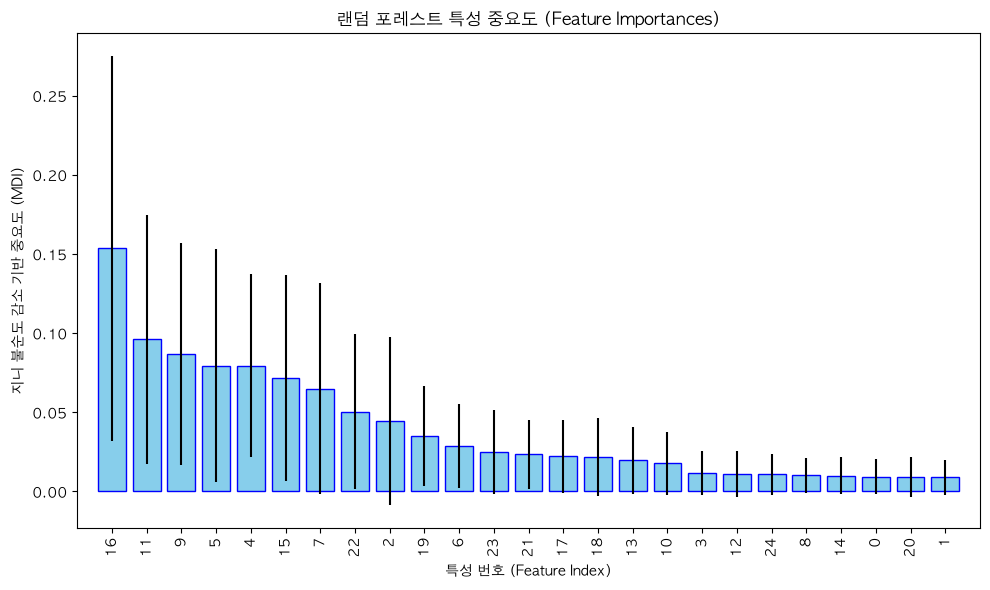

In [5]:
import sys
import platform
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# OS별 한글 폰트 및 마이너스 깨짐 방지 설정
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif os_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 가상 분류 데이터셋 생성
# 총 25개 특성(n_features) 중 15개만 유의미한 정보(n_informative)를 가지도록 설정
X, y = make_classification(
    n_samples=500,
    n_features=25,
    n_clusters_per_class=1,
    n_informative=15,
    random_state=123
)

# 2. 랜덤 포레스트 모델 생성 및 학습
rf = RandomForestClassifier(n_estimators=250, random_state=123)
rf.fit(X, y)

# 3. 특성 중요도(MDI, Mean Decrease in Impurity) 및 개별 트리 간 표준편차 계산
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# 중요도 기준 내림차순 정렬 인덱스 추출
indices = np.argsort(importances)[::-1]

# 4. 상위 특성 중요도 텍스트 출력
print("=== 특성 중요도 순위 (상위 10개) ===")
for f in range(10):
    print(f"{f + 1:2d}. Feature {indices[f]:2d} : {importances[indices[f]]:.4f}")

# 5. 특성 중요도 바 차트 시각화 (오차 막대: 트리 간 편차)
plt.figure(figsize=(10, 6))
plt.title("랜덤 포레스트 특성 중요도 (Feature Importances)")
plt.bar(
    range(X.shape[1]),
    importances[indices],
    yerr=std[indices],
    align="center",
    color="skyblue",
    edgecolor="blue"
)
plt.xticks(range(X.shape[1]), indices, rotation=90)
plt.xlim([-1, X.shape[1]])
plt.xlabel("특성 번호 (Feature Index)")
plt.ylabel("지니 불순도 감소 기반 중요도 (MDI)")
plt.tight_layout()
plt.show()

- **지니 불순도 감소 기반 중요도 (MDI, Mean Decrease in Impurity)**
    - `rf.feature_importances_`는 각 특성이 트리 노드 분기 시 **불순도(지니 불순도)를 얼마나 감소시켰는지** 전체 나무에 대해 평균을 낸 수치이다. (모든 중요도의 합은 $1.0$)
- **오차 막대 (`yerr=std[indices]`)**
    - 250개 개별 결정 트리들이 측정한 특성 중요도의 **표준편차**를 오차 막대로 표시하여, 특정 특성의 중요도가 전체 숲에서 얼마나 안정적으로 평가되었는지 보여준다.
- **유의미한 특성 식별**
    - `n_informative=15` 설정에 따라 그래프상 상위 15개 특성은 높은 중요도를 나타내고, 나머지 10개 비유의미(Noise) 특성은 $0$에 가까운 중요도를 나타낸다.

In [6]:
# 2. 비교 대상 모델 리스트 정의 (인덱스, 라벨, 모델 객체)
ensemble_clfs = [(0, "max_features = 'sqrt'",
                  RandomForestClassifier(warm_start=True,
                                         oob_score=True,
                                         max_features="sqrt",
                                         random_state=123)),
                 (1, "max_features = 'log2'",
                  RandomForestClassifier(warm_start=True,
                                         max_features="log2",
                                         oob_score=True,
                                         random_state=123)),
                 (2, "max_features = None",
                  RandomForestClassifier(warm_start=True,
                                         max_features=None,
                                         oob_score=True,
                                         random_state=123))]

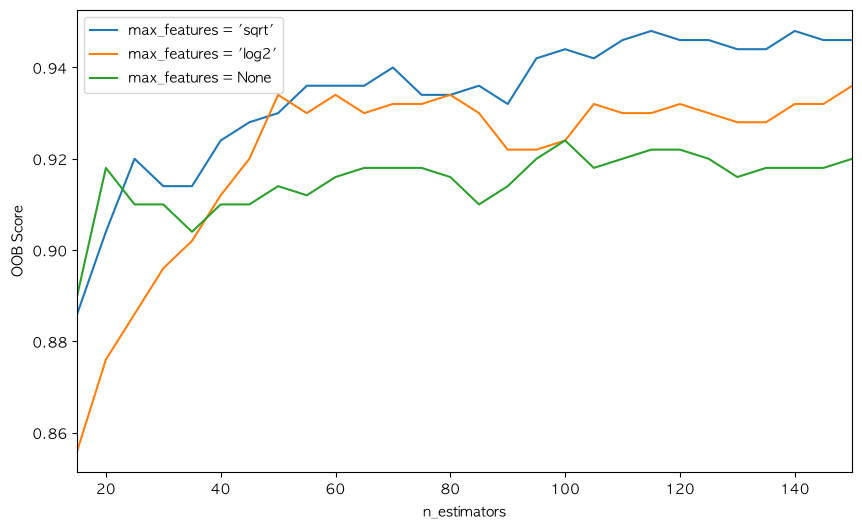

In [7]:
# 3. OOB 점수를 저장할 빈 리스트 생성
min_estimators = 15
max_estimators = 150

oob_scores = [[], [], []]

# 4. 각 모델별로 트리 개수를 5개씩 늘려가며 학습 및 OOB Score(정확도) 수집
for ind, label, clf in ensemble_clfs:
    for i in range(min_estimators, max_estimators + 1, 5):
        clf.set_params(n_estimators=i)  # warm_start=True로 인해 기존 트리에 i개까지 추가 학습
        clf.fit(X, y)
        oob_scores[ind].append((i, clf.oob_score_))  # (트리 수, OOB 정확도) 저장


# 5. 모델별 OOB Score 변화 곡선 시각화
plt.figure(figsize=(10, 6))
for i in range(len(ensemble_clfs)):
    xs, ys = zip(*oob_scores[i])
    plt.plot(xs, ys, label=ensemble_clfs[i][1])

plt.xlim(min_estimators, max_estimators)
plt.xlabel("n_estimators")
plt.ylabel("OOB Score")
plt.legend(loc="best")

### [예제 7.2] 랜덤 포레스트 분류 모델의 피처 중요도

In [8]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

X, y = make_classification(n_samples=1000,
                           n_features=10,
                           n_informative=3,
                           n_redundant=0,
                           n_classes=2,
                           random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    stratify=y,
                                                    random_state=42)

In [9]:
feature_names = [f"feature {i}" for i in range(X.shape[1])]
forest = RandomForestClassifier(random_state=0).fit(X_train, y_train)

In [10]:
start_time = time.time()
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)
print(f'MDI 기반 피처 중요도 산출 소요 시간:{time.time() - start_time: .3f}초')

MDI 기반 피처 중요도 산출 소요 시간: 0.005초


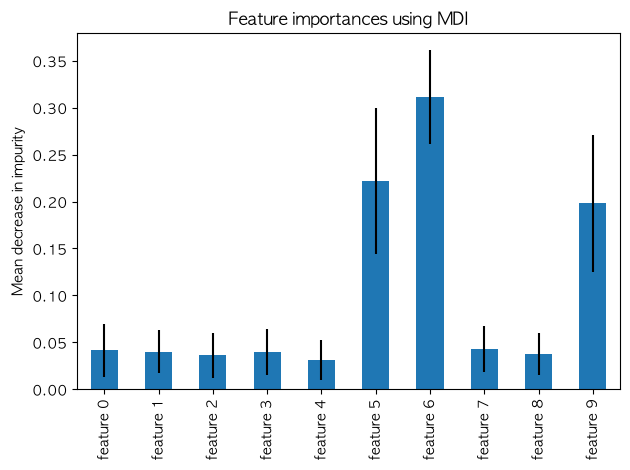

In [11]:
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [12]:
from sklearn.inspection import permutation_importance

start_time = time.time()
result = permutation_importance(forest,
                                X_test,
                                y_test,
                                n_repeats=10,
                                random_state=0)
print(f'퍼뮤테이션 기반 피처 중요도 산출 소요 시간:{time.time() - start_time: .3f}초')

forest_importances = pd.Series(result.importances_mean, index=feature_names)

퍼뮤테이션 기반 피처 중요도 산출 소요 시간: 0.698초


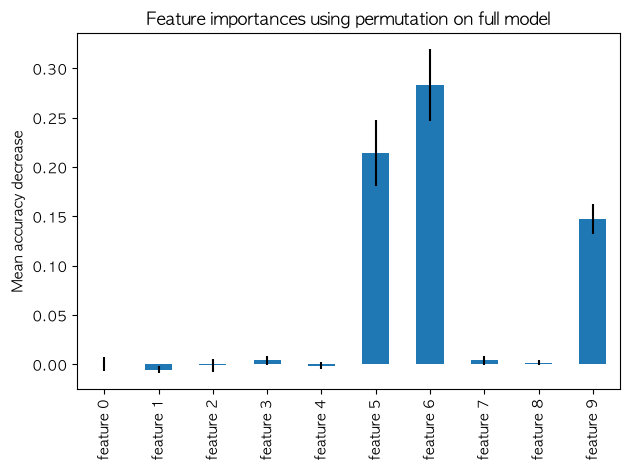

In [13]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title('Feature importances using permutation on full model')
ax.set_ylabel('Mean accuracy decrease')
fig.tight_layout()
plt.show()

## 07 되새김 문제

### [되새김 문제 7.1] RandomForestClassifier 클래스 적용하기

#### 문제

In [14]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=1234)

#### 풀이

In [15]:
clf = RandomForestClassifier(random_state=1234,
                             n_estimators=50,
                             criterion='gini',
                             max_depth=4,
                             max_features='log2')

y_pred = clf.fit(X_train, y_train).predict(X_test)
print(f'정확도:{(y_pred == y_test).mean() * 100: .2f}%')

정확도: 98.00%


### [되새김 문제 7.2] 랜덤 포레스트 회귀 모델 구현하기

#### 문제

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=1234)
train = pd.concat([X_train, y_train], axis=1)
X_cols, y_col = X.columns.tolist(), y.name

#### 풀이

In [17]:
max_depth = 3
min_samples_split = 4

In [18]:
def eval_mse(left, right, y_col):
    mse, n1, n2 = 0, len(left), len(right)
    score = ((left[y_col] - left[y_col].mean())**2).mean()
    mse += score * n1 / (n1 + n2)
    score = ((right[y_col] - right[y_col].mean())**2).mean()
    mse += score * n2 / (n1 + n2)
    return mse

def eval_y(df, y_col):
    return df[y_col].mean()

def base_tree(train, X_cols, y_col, max_depth=4, min_samples_split=4):
    tree = []
    for i in range(0, 2**(max_depth + 1)):
        tree.append(dict({'struct': None}))
    tree[1]['struct'] = train
    for i in range(1, len(tree)):
        if not isinstance(tree[i]['struct'], pd.DataFrame): continue
        if i >= 2**max_depth:
            tree[i]['struct'] = eval_y(tree[i]['struct'], y_col)
            continue

        data = tree[i]['struct']
        a, b, c, d, e = '', float('inf'), float('inf'), None, None
        for X_col in X_cols:
            vals = np.sort(data[X_col].unique())
            for val in vals[1:]:
                left, right = data[data[X_col] < val], data[data[X_col] >= val]
                mse = eval_mse(left, right, y_col)
                if mse < c: a, b, c, d, e = X_col, val, mse, left, right
        tree[i]['col'] = a
        tree[i]['val'] = b
        if len(d) >= min_samples_split: tree[i << 1]['struct'] = d
        else: tree[i << 1]['struct'] = eval_y(e, y_col)

        if len(e) >= min_samples_split: tree[(i << 1) + 1]['struct'] = e
        else: tree[(i << 1) + 1]['struct'] = eval_y(e, y_col)
    return tree

In [19]:
max_samples = 0.3
forest = []

for i in range(5):
    train0 = train.sample(frac=max_samples, random_state=123)
    forest.append(base_tree(train0, X_cols, y_col))

In [20]:
mae = 0
for i in range(len(X_test)):
    row = X_test.iloc[i]
    y_pred = 0
    for tree in forest:
        ind = 1
        node = tree[ind]
        while isinstance(node['struct'], pd.DataFrame):
            if row[node['col']] < node['val']: ind = ind << 1
            else: ind = (ind << 1) + 1

            node = tree[ind]
        y_pred += node['struct']

    y_pred = y_pred / len(forest)
    mae += np.abs(y_pred - y_test.iloc[i])

print(f'테스트 데이터셋 기준 MAE:{mae / len(y_test): .2f}')

테스트 데이터셋 기준 MAE: 46.28


In [21]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(n_estimators=5,
                            random_state=1234,
                            max_depth=3,
                            min_samples_split=4)
y_pred = reg.fit(X_train, y_train).predict(X_test)
print(f'RandomForestRegressor로 학습한 모델의 테스트 데이터셋 기준 MAE:{(np.abs(y_pred - y_test)).mean(): .2f}')

RandomForestRegressor로 학습한 모델의 테스트 데이터셋 기준 MAE: 45.39


### [되새김 문제 7.3] 퍼뮤테이션 기반 피처 중요도 계산하기

#### 문제

In [22]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes(as_frame=True)
X_train, X_val, y_train, y_val = train_test_split(diabetes.data,
                                                  diabetes.target,
                                                  random_state=0)

#### 풀이

In [23]:
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

model = Ridge(alpha=1e-2).fit(X_train, y_train)

pi = permutation_importance(model,
                            X_val,
                            y_val,
                            n_repeats=30,
                            random_state=0,
                            scoring='neg_mean_squared_error')

pi_series = pd.Series(pi.importances_mean, index=X_train.columns)
print(f'퍼뮤테이션 기반 피처별 중요도: {pi_series.sort_values(ascending=False).values[:3]}')

퍼뮤테이션 기반 피처별 중요도: [1013.86634639  872.72567747  438.66275116]
